# Structured Jet — MCMC Run (improved pipeline)

This notebook runs the full Bayesian inference pipeline for the **power-law structured-jet model** using the improved `src/structured_jet` package.

## Key improvements over the original MAGGPY_fj notebook

| # | Fix | Reference |
|---|-----|-----------|
| §1.1 | RNG reset bug removed from likelihood | `montecarlo.py` |
| §1.2 | Per-call local RNG for CvM scoring | `montecarlo.py` |
| §2.1 | GBM_EFF documented with citation | `montecarlo.py` |
| §2.2 | Hard flux cut kept (catalogue was built with it) | `montecarlo.py` |
| §2.4 | T₉₀ double-cut fixed with 3× safety factor | `montecarlo.py` |
| §3.1 | Explicit L_min cut after Schechter draw | `montecarlo.py` |
| §4.4 | `log_likelihood_` deprecated; `log_likelihood_fj` canonical | `montecarlo.py` |
| §6.1 | R_F / R_E clamped at table boundaries | `data_io.py` |

## Poisson term and fj inference

The MC draw size is the **geometric exposure** — every BNS merger in our sky cone over the catalogue duration:

$$
N_{\rm events} = N_{\rm BNS/yr} \times n_{\rm years} \times \epsilon_{\rm geo}
$$

Each merger gets a full physics draw.  The fraction that survive the detection cuts is $\hat\eta_{\rm det}$.  
$f_j$ then appears **only** in the Poisson rate term:

$$
\mu = N_{\rm events} \times f_j \times \epsilon_{\rm GBM} \times \hat\eta_{\rm det}
  = N_{\rm triggered} \times f_j \times \epsilon_{\rm GBM}
$$

compared to the observed count $k = \dot{N}_{\rm obs} \times n_{\rm years}$ via a Poisson log-likelihood.

The MCMC asks: *"given ~16 yr of BNS mergers in our sky cone, what fraction $f_j$ must have launched a detectable sGRB jet to reproduce the observed ~300 sGRBs?"*

## 1. Setup

In [6]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import emcee
from math import inf
from pathlib import Path

# Add repo root to path when running from Paper_Notebooks/
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# ── improved structured-jet pipeline ────────────────────────────────────────
from src.structured_jet import (
    initialize_simulation,
    log_likelihood_fj,
    make_observations,
    generate_grb_population,
    DEFAULT_LIMITS,
    GBM_EFF,
    L_MIN_FACTOR,
    N_YEARS_DEFAULT,
    create_log_prior,
    initialize_walkers,
    DEFAULT_PRIOR_BOUNDS,
)
from src.init import create_run_dir
from src.multiprocessing_MC import run_mcmc_parallel

plt.style.use('../configurations/style.mplstyle')

print(f"GBM_EFF      = {GBM_EFF}")
print(f"L_MIN_FACTOR = {L_MIN_FACTOR}")
print(f"N_YEARS_DEFAULT (catalogue duration) = {N_YEARS_DEFAULT} yr")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
GBM_EFF      = 0.6
L_MIN_FACTOR = 0.0001
N_YEARS_DEFAULT (catalogue duration) = 16.0 yr


## 2. Output directory

In [7]:
datafiles  = Path("../datafiles")
output_dir = create_run_dir(
    "structured_jet/fj_run_free_fj",
    output_files_default="../Output_files",
)
print(f"Output directory: {output_dir}")

Loading existing directory  : ../Output_files/structured_jet/fj_run_free_fj
Output directory: ../Output_files/structured_jet/fj_run_free_fj


## 3. Model parameters

The jet structure is fixed at `s = 4.0`, `θ_c = 3.4°` (from GW170817 constraints).  
Spectral parameters follow the GBM population average.  
See §5.2 of the code review if `s` needs to be promoted to a free parameter.

In [8]:
params = {
    # ── spectral shape ──────────────────────────────────────────────────────
    "alpha"       : -0.67,   # low-energy photon index (synchrotron: -2/3)
    "beta_s"      : -2.59,   # high-energy photon index (GBM population average)
    "n"           : 2,       # SBPL smoothness parameter
    # ── jet geometry ────────────────────────────────────────────────────────
    "theta_c"     : 3.4,     # core half-opening angle [deg]  (GW170817)
    "theta_v_max" : 10,      # maximum viewing angle [deg]
    # ── redshift model ──────────────────────────────────────────────────────
    # Uses the fiducial BNS population (Hrad channel, CE alpha=1.0).
    # z_arr for this model represents 1 year of BNS mergers.
    "z_model"     : "fiducial_Hrad_A1.0",
}

print("Model parameters:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

Model parameters:
  alpha           = -0.67
  beta_s          = -2.59
  n               = 2
  theta_c         = 3.4
  theta_v_max     = 10
  z_model         = fiducial_Hrad_A1.0


## 4. Initialise simulation

`structured_jet.initialize_simulation` calls the parent `init.initialize_simulation` then
patches `SimParams.R_F` and `SimParams.R_E` with **clamped** interpolators (§6.1).

In [9]:
sim_params, interps, data_dict = initialize_simulation(datafiles, params)

# ── catalogue summary ───────────────────────────────────────────────────────
n_years = sim_params.triggered_years   # catalogue duration used by log_likelihood_fj
n_bns_yr = len(sim_params.z_arr)

print(f"\nCatalogue duration    : {n_years:.1f} yr")
print(f"Observed yearly rate  : {sim_params.yearly_rate:.2f} sGRBs/yr")
print(f"BNS per year (z_arr)  : {n_bns_yr:,}")
print(f"Catalogue sGRBs       : {sim_params.yearly_rate * n_years:.0f}")
print()
print("Detection limits (hard cuts applied in catalogue preparation):")
for k, v in DEFAULT_LIMITS.items():
    print(f"  {k:15s} = {v}")
print()
# §2.2 note
print("NOTE (§2.2): The flux cut F_LIM is applied identically in the simulation")
print("  and the catalogue.  It corresponds to 4 ph/cm²/s in the 50-300 keV")
print("  BATSE band (= GBM trigger band).  No sigmoid model is applied.")

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year

Catalogue duration    : 17.5 yr
Observed yearly rate  : 18.58 sGRBs/yr
BNS per year (z_arr)  : 359,079
Catalogue sGRBs       : 325

Detection limits (hard cuts applied in catalogue preparation):
  F_LIM           = 4
  T90_LIM         = 2
  EP_LIM_UPPER    = 10000
  EP_LIM_LOWER    = 50

NOTE (§2.2): The flux cut F_LIM is applied identically in the simulation
  and the catalogue.  It corresponds to 4 ph/cm²/s in the 50-300 keV
  BATSE band (= GBM trigger band).  No sigmoid model is applied.


## 5. Prior and walker initialisation

In [10]:
# ── prior bounds ────────────────────────────────────────────────────────────
# §3.2: k lower bound at 1.5 avoids divergent mean; upper at 6 prevents
# excessively top-heavy luminosity functions.
prior_bounds        = dict(DEFAULT_PRIOR_BOUNDS)  # copy defaults
prior_bounds["f_j"] = (0, 20)
print("Prior bounds:")
for name, (lo, hi) in prior_bounds.items():
    print(f"  {name:12s}: [{lo}, {hi}]")

log_prior = create_log_prior(prior_bounds)

Prior bounds:
  k           : [1.5, 6]
  L_L0        : [-3, 2]
  L_mu_E      : [2.5, 5]
  sigma_E     : [0, 1]
  L_mu_tau    : [-2, 2.5]
  sigma_tau   : [0, 1.8]
  f_j         : [0, 20]


In [11]:
# ── log-probability = log-prior + log_likelihood_fj ─────────────────────────
#
# MC draw size is the geometric exposure:
#   n_events = N_BNS/yr × n_years × geo_eff
#
# This is the number of BNS mergers in our sky cone over the full catalogue
# duration.  Every merger gets a full physics draw (L, Ep, t_peak, theta_v).
# The fraction that survive the detection cuts = eta_det.
#
# fj enters ONLY in the Poisson rate term:
#   mu = triggered_events × fj × GBM_eff
#
# The MCMC asks: "given ~16 yr of BNS mergers in our cone, what fraction fj
# must have launched a detectable sGRB to reproduce the observed count?"
#
# §1.1 – RNG never reset inside log_likelihood_fj
# §1.2 – per-call local RNG seeded from hash(thetas) for CvM scoring

def log_probability(thetas):
    lp = log_prior(thetas)
    if not np.isfinite(lp):
        return -inf, None, None, None, None, None
    ll, yr_rate, lE, lT, lP, lF = log_likelihood_fj(
        thetas,
        sim_params,
        interps,
        limits=DEFAULT_LIMITS,
    )
    return lp + ll, yr_rate, lE, lT, lP, lF

# ── quick sanity check ───────────────────────────────────────────────────────
geo_eff   = 1 - np.cos(sim_params.theta_v_max)
n_events_check = int(len(sim_params.z_arr) * n_years * geo_eff)
print(f"Geometric MC draw size : {n_events_check:,}  events")
print(f"  = {len(sim_params.z_arr):,} BNS/yr  ×  {n_years:.1f} yr  ×  {geo_eff:.4f} (geo_eff)")

thetas_test = [2.5, -0.5, 3.2, 0.35, -0.3, 0.7, 0.15]
result = log_probability(thetas_test)
print(f"\nlog_prob at test point : {result[0]:.3f}")
print(f"simulated yearly rate  : {result[1]}")

Geometric MC draw size : 95,440  events
  = 359,079 BNS/yr  ×  17.5 yr  ×  0.0152 (geo_eff)

log_prob at test point : -101.359
simulated yearly rate  : 5.0156184981321825


## 6. Walkers

In [12]:
N_WALKERS = 32
N_STEPS   = 2000
N_DIM     = 7    # [k, L_L0, L_mu_E, sigma_E, L_mu_tau, sigma_tau, fj]

initial_pos = initialize_walkers(N_WALKERS, seed=42, max_fj=0.8)
print(f"Walkers : {initial_pos.shape}")
print(f"fj range: [{initial_pos[:, -1].min():.3f}, {initial_pos[:, -1].max():.3f}]")

Walkers : (32, 7)
fj range: [0.402, 0.760]


## 7. MCMC run

Blobs store per-step diagnostics: `(yearly_rate, logL_epeak, logL_t90, logL_pflux, logL_fluence)`.  
The backend writes incrementally to disk so the run can be resumed after interruption.

In [ ]:
backend_file = output_dir / "emcee.h5"

blobs_dtype = [
    ("yearly_rate",  float),
    ("logL_epeak",   float),
    ("logL_t90",     float),
    ("logL_pflux",   float),
    ("logL_fluence", float),
]

# Create (or re-open) the HDF5 backend — resume-aware
backend = emcee.backends.HDFBackend(str(backend_file))
 
run_mcmc_parallel(
    log_probability = log_probability,
    initial_pos     = initial_pos,
    max_n           = N_STEPS,       # run_mcmc_parallel uses max_n
    backend         = backend,       # pass the backend object, not a path
    blobs_dtype     = blobs_dtype,
    progress        = True,
)

print(f"\nChain saved to {backend_file}")

Running MCMC with 11 workers (2000 steps)...


100%|██████████| 2000/2000 [05:16<00:00,  6.32it/s]

✓ MCMC complete (parallel). Mean acceptance: 0.067

Chain saved to ../Output_files/structured_jet/fj_run_free_fj/emcee.h5


## 8. Chain diagnostics

In [14]:
# Re-open the backend as read-only for analysis
reader = emcee.backends.HDFBackend(str(backend_file), read_only=True)
print(f"Chain shape : {reader.get_chain().shape}   (steps, walkers, ndim)")
print(f"Acceptance  : {reader.accepted.mean() / reader.iteration:.3f} (mean fraction)")

try:
    tau = reader.get_autocorr_time(tol=0)
    print(f"\nAutocorrelation times:")
    param_names = ["k", "L_L0", "L_mu_E", "sigma_E", "L_mu_tau", "sigma_tau", "fj"]
    for n, t in zip(param_names, tau):
        print(f"  {n:12s}: {t:.1f} steps")
    burn_in = int(3 * np.max(tau))
    thin    = max(1, int(0.5 * np.min(tau)))
    print(f"\nSuggested burn-in : {burn_in} steps")
    print(f"Suggested thinning: every {thin} steps")
except emcee.autocorr.AutocorrError as e:
    print(f"Autocorr not converged yet: {e}")
    burn_in = N_STEPS // 4
    thin    = 1

Chain shape : (2000, 32, 7)   (steps, walkers, ndim)
Acceptance  : 0.067 (mean fraction)

Autocorrelation times:
  k           : 206.3 steps
  L_L0        : 168.5 steps
  L_mu_E      : 152.9 steps
  sigma_E     : 147.4 steps
  L_mu_tau    : 166.1 steps
  sigma_tau   : 170.3 steps
  fj          : 199.4 steps

Suggested burn-in : 619 steps
Suggested thinning: every 73 steps


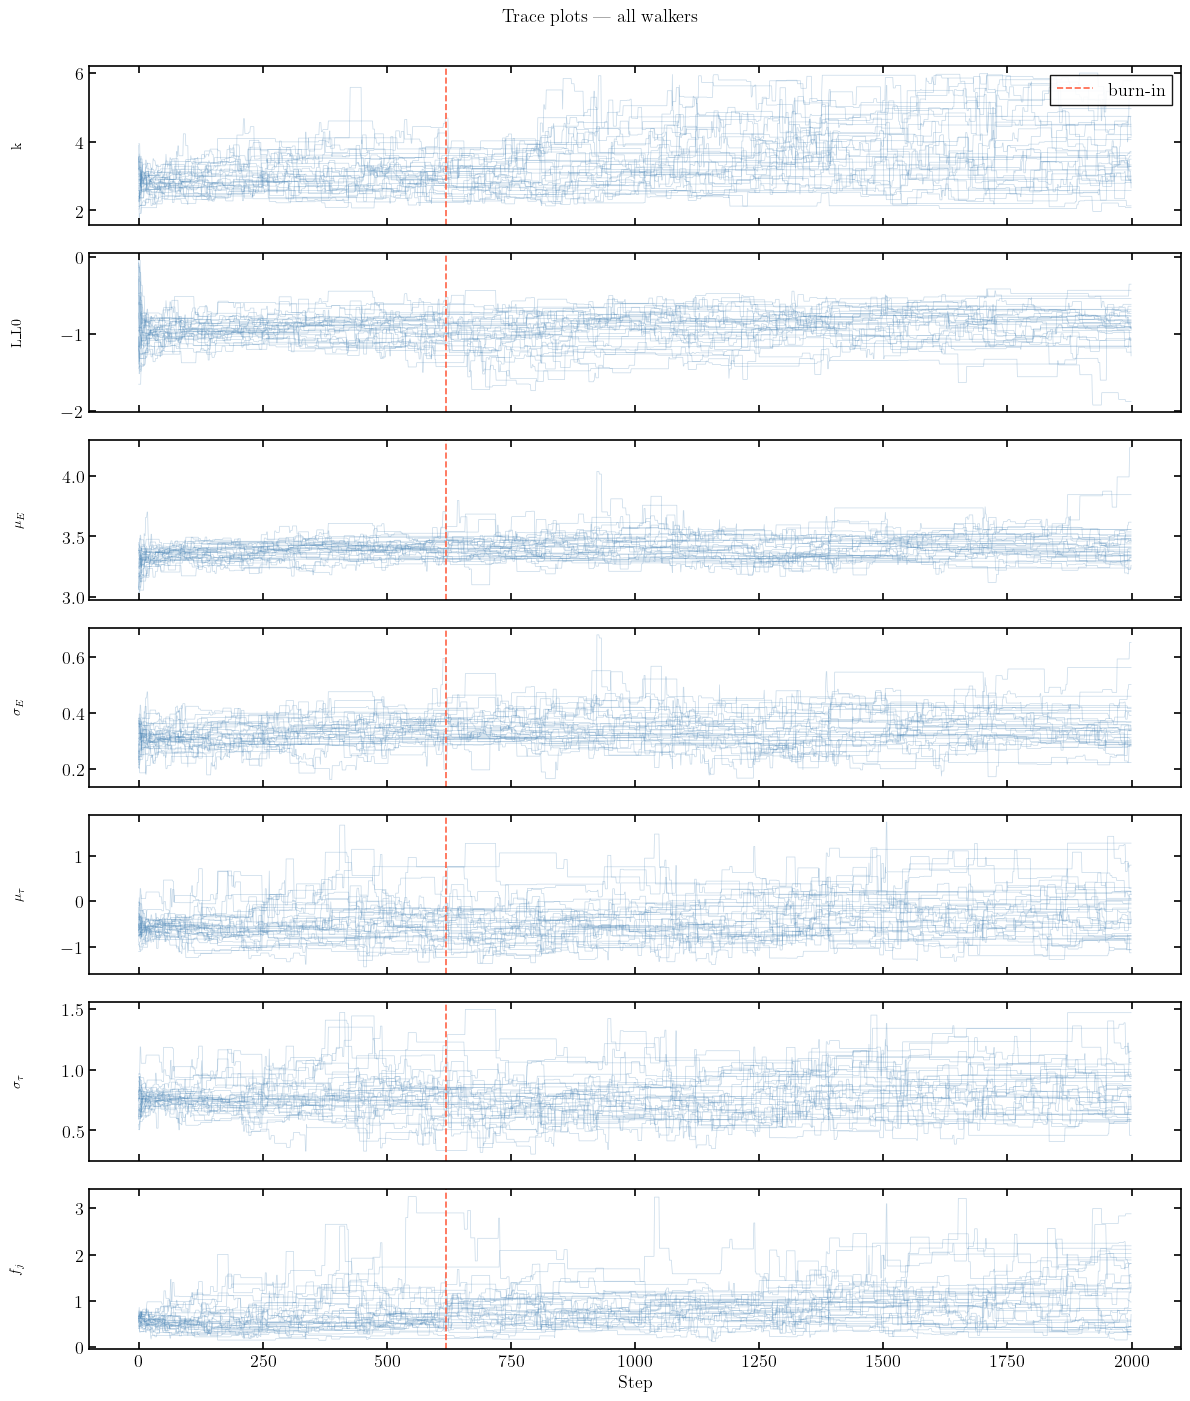

In [15]:
param_names = ["k", "L_L0", r"$\mu_E$", r"$\sigma_E$", r"$\mu_\tau$", r"$\sigma_\tau$", r"$f_j$"]

chain = reader.get_chain()   # (steps, walkers, ndim)

fig, axes = plt.subplots(N_DIM, 1, figsize=(12, 14), sharex=True)
for i, (ax, name) in enumerate(zip(axes, param_names)):
    ax.plot(chain[:, :, i], alpha=0.3, lw=0.5, color="steelblue")
    ax.axvline(burn_in, color="tomato", ls="--", lw=1.2, label="burn-in" if i == 0 else None)
    ax.set_ylabel(name, fontsize=10)
    ax.yaxis.set_label_coords(-0.06, 0.5)
axes[-1].set_xlabel("Step")
axes[0].legend(loc="upper right")
fig.suptitle("Trace plots — all walkers", fontsize=13, y=1.001)
fig.tight_layout()
fig.savefig(output_dir / "trace_plots.pdf", bbox_inches="tight")
plt.show()

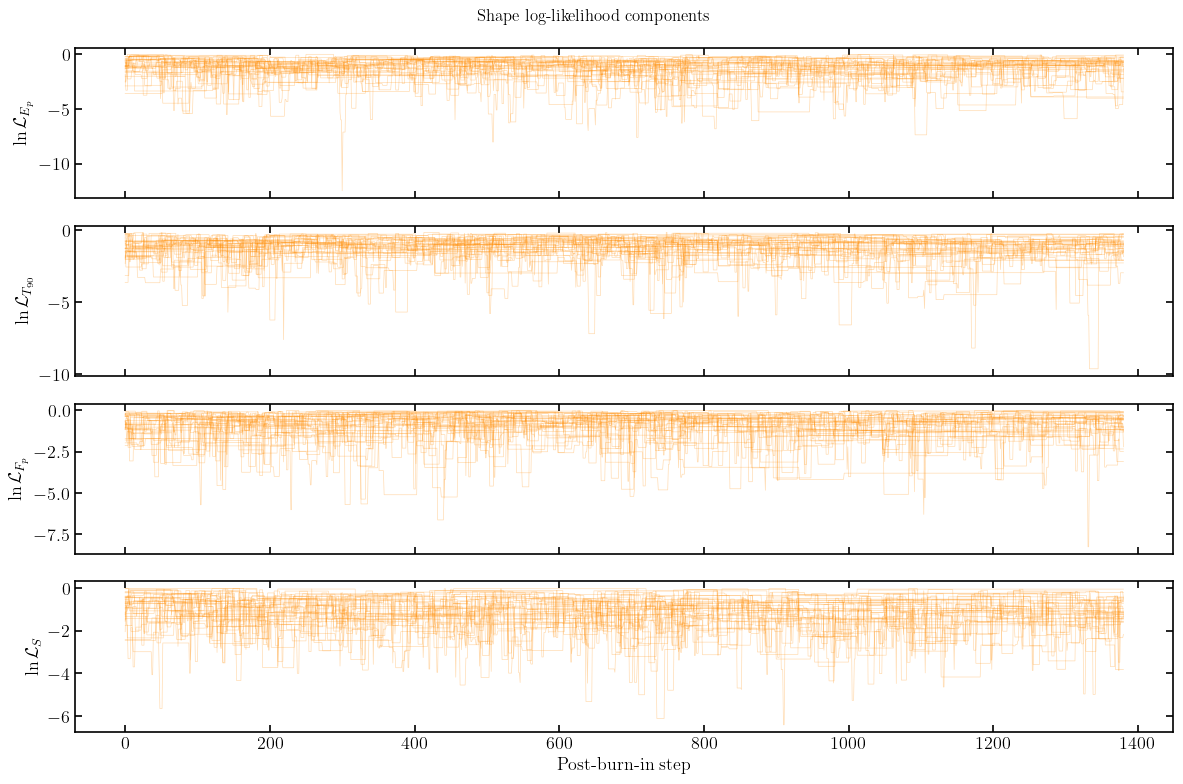

In [16]:
# ── per-component likelihood trace ──────────────────────────────────────────
blobs  = reader.get_blobs()   # structured array: (steps, walkers)
logL_components = {
    r"$\ln\mathcal{L}_{E_p}$"  : blobs["logL_epeak"][burn_in:],
    r"$\ln\mathcal{L}_{T_{90}}$": blobs["logL_t90"][burn_in:],
    r"$\ln\mathcal{L}_{F_p}$"   : blobs["logL_pflux"][burn_in:],
    r"$\ln\mathcal{L}_{S}$"     : blobs["logL_fluence"][burn_in:],
}

fig, axes = plt.subplots(len(logL_components), 1, figsize=(12, 8), sharex=True)
for ax, (label, vals) in zip(axes, logL_components.items()):
    ax.plot(vals, alpha=0.3, lw=0.5, color="darkorange")
    ax.set_ylabel(label)
axes[-1].set_xlabel("Post-burn-in step")
fig.suptitle("Shape log-likelihood components", fontsize=12)
fig.tight_layout()
fig.savefig(output_dir / "logL_components.pdf", bbox_inches="tight")
plt.show()

## 9. Posterior corner plot

/home/ludo/miniconda3/envs/acme_env/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Flat samples shape: (576, 7)


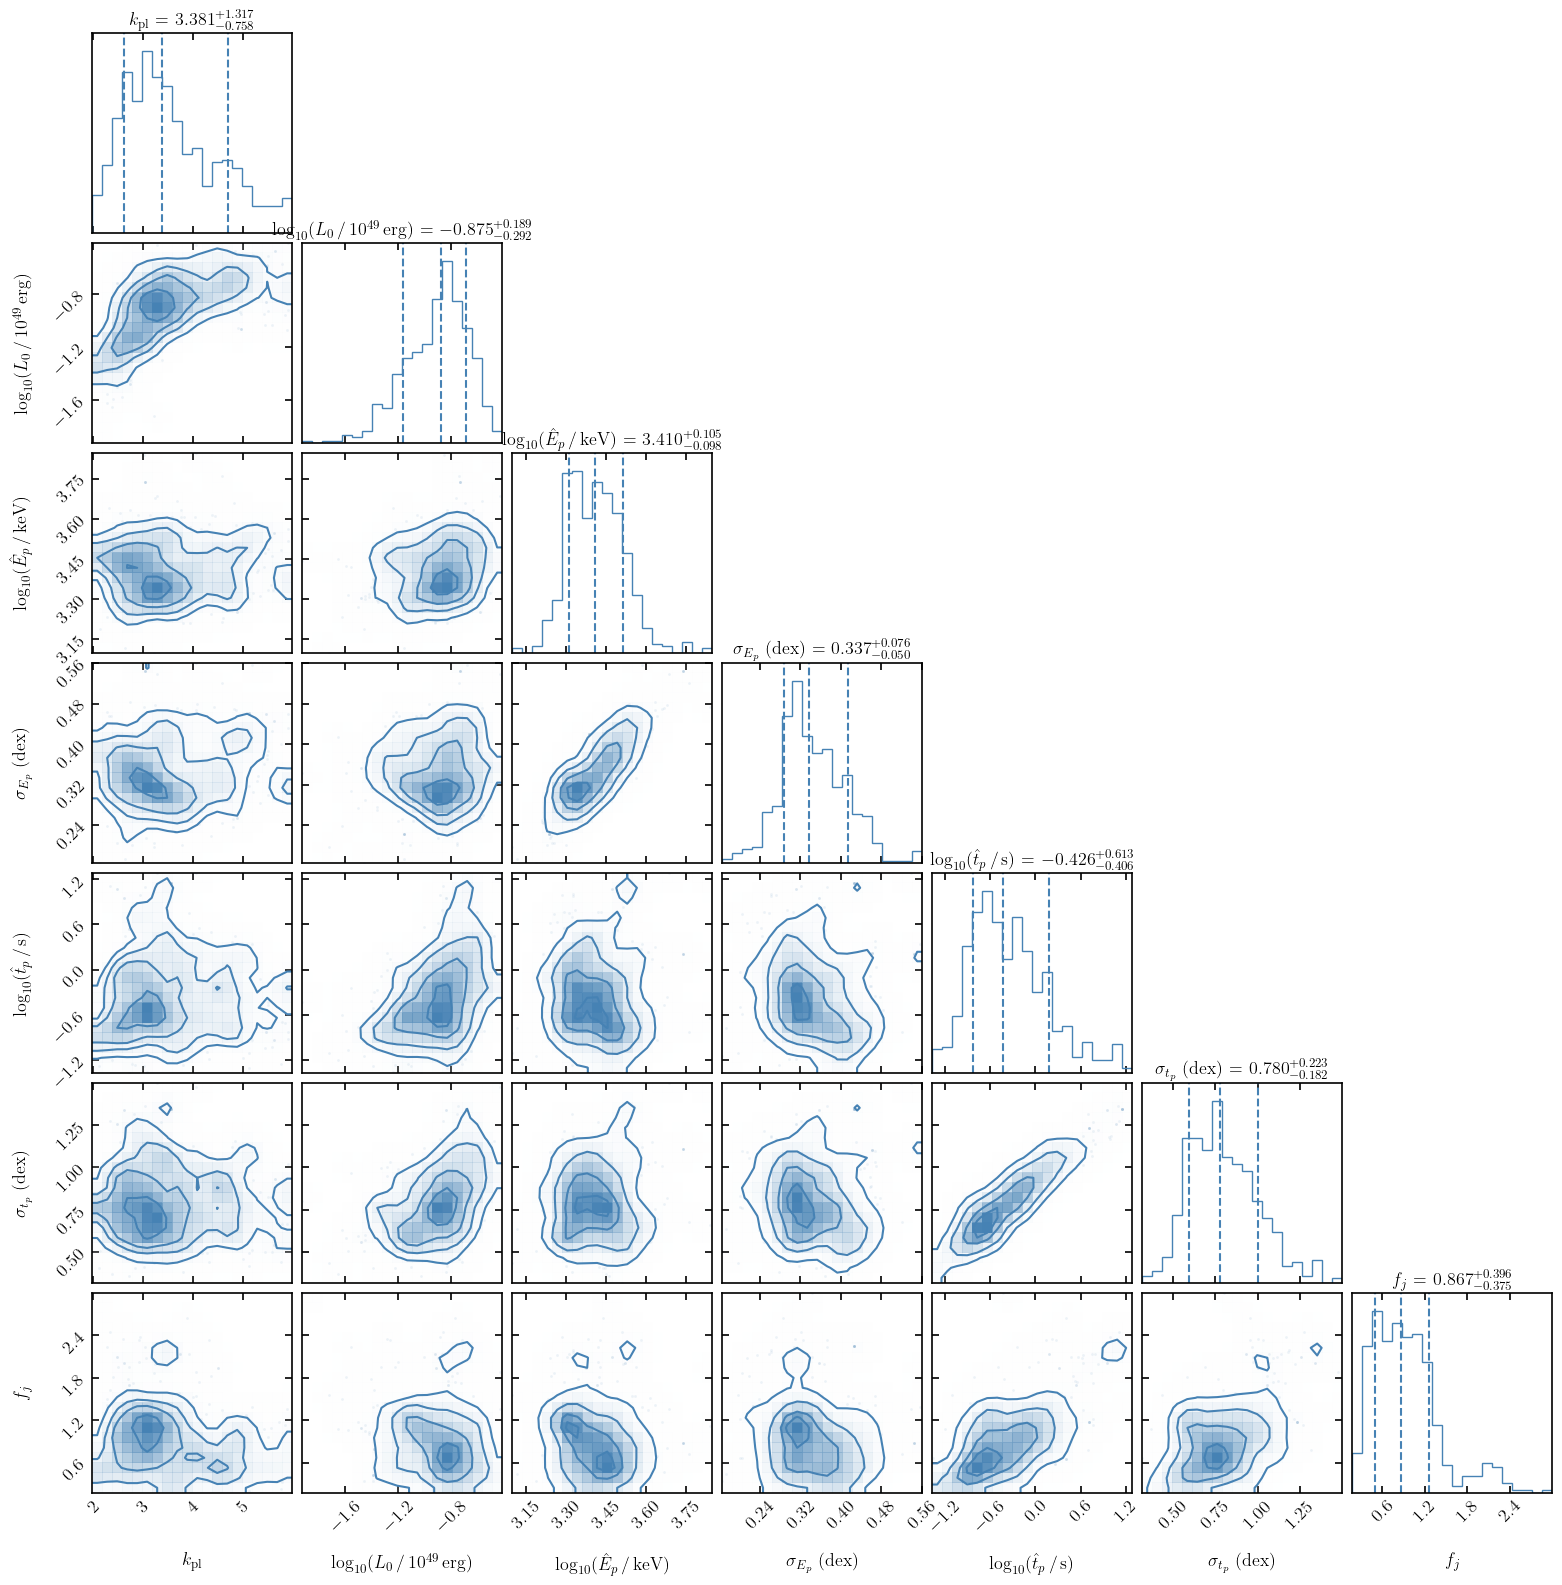


Posterior medians and 1-σ intervals:
  $k_{\rm pl}$                                 : +3.381  +1.317  -0.758
  $\log_{10}(L_0\,/\,10^{49}\,{\rm erg})$      : -0.875  +0.189  -0.292
  $\log_{10}(\hat{E}_p\,/\,{\rm keV})$         : +3.410  +0.105  -0.098
  $\sigma_{E_p}$  (dex)                        : +0.337  +0.076  -0.050
  $\log_{10}(\hat{t}_p\,/\,{\rm s})$           : -0.426  +0.613  -0.406
  $\sigma_{t_p}$  (dex)                        : +0.780  +0.223  -0.182
  $f_j$                                        : +0.867  +0.396  -0.375


In [17]:
try:
    import corner
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "corner", "-q"])
    import corner

flat_samples = reader.get_chain(discard=burn_in, thin=thin, flat=True)
print(f"Flat samples shape: {flat_samples.shape}")

param_labels = [
    r"$k_{\rm pl}$",
    r"$\log_{10}(L_0\,/\,10^{49}\,{\rm erg})$",
    r"$\log_{10}(\hat{E}_p\,/\,{\rm keV})$",
    r"$\sigma_{E_p}$  (dex)",
    r"$\log_{10}(\hat{t}_p\,/\,{\rm s})$",
    r"$\sigma_{t_p}$  (dex)",
    r"$f_j$",
]

fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    smooth=1.0,
    color="steelblue",
)
fig.savefig(output_dir / "corner_posterior.pdf", bbox_inches="tight")
plt.show()

# Print median + 1-sigma
print("\nPosterior medians and 1-σ intervals:")
for label, p in zip(param_labels, flat_samples.T):
    lo, med, hi = np.percentile(p, [16, 50, 84])
    print(f"  {label:45s}: {med:+.3f}  +{hi-med:.3f}  -{med-lo:.3f}")

## 10. Posterior predictive check (PPC)

Draw $N_{\rm PPC}$ samples from the flat posterior and generate a synthetic catalogue for each.  
Compare simulated and observed distributions of the four observables.

In [18]:
N_PPC = 200   # number of posterior samples to use

# For PPC we use the same geometric exposure as the likelihood so the
# simulated catalogue and the observed one have matching effective volumes.
# n_events_check was computed in the logprob cell.
rng_ppc = np.random.default_rng(0)
idx_ppc = rng_ppc.integers(0, len(flat_samples), N_PPC)
ppc_samples = flat_samples[idx_ppc]

ppc_results = []
for theta in ppc_samples:
    pop = generate_grb_population(
        theta, sim_params, interps,
        limits=DEFAULT_LIMITS,
        n_events=n_events_check,
    )
    if pop is not None:
        ppc_results.append(pop)

print(f"MC draw size per PPC realisation : {n_events_check:,}")
print(f"PPC realisations with detections : {len(ppc_results)} / {N_PPC}")

MC draw size per PPC realisation : 95,440
PPC realisations with detections : 200 / 200


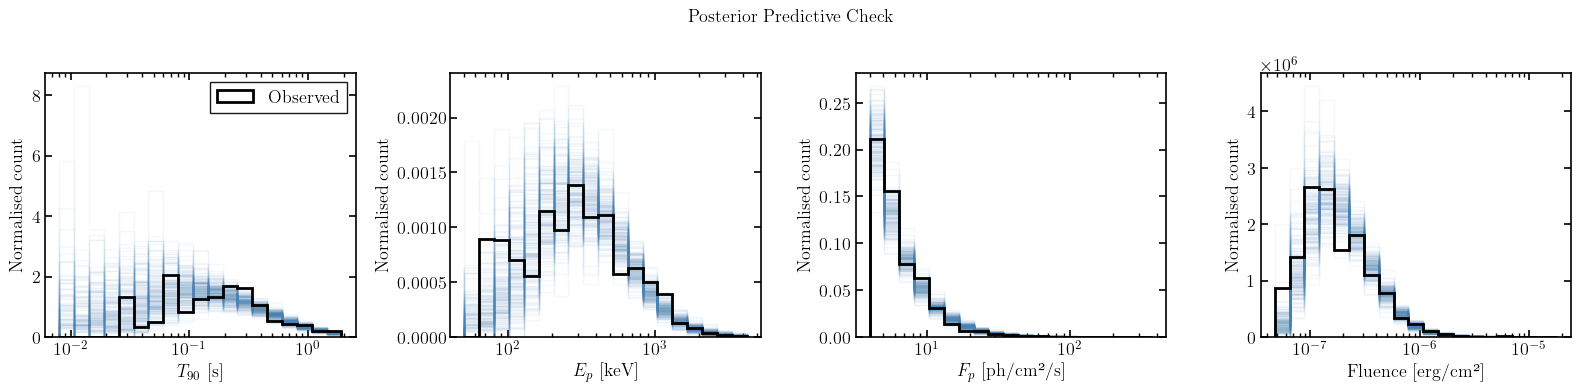

In [19]:
obs_data = {
    r"$T_{90}$ [s]"            : (sim_params.duration_data, "t90",     "log"),
    r"$E_p$ [keV]"             : (sim_params.epeak_data,    "epeak",   "log"),
    r"$F_p$ [ph/cm²/s]"        : (sim_params.pflux_data,    "pflux",   "log"),
    r"Fluence [erg/cm²]"       : (sim_params.fluence_data,  "fluence", "log"),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, (obs, key, scale)) in zip(axes, obs_data.items()):
    # Observed
    bins = np.logspace(np.log10(obs.min()), np.log10(obs.max()), 20)
    ax.hist(obs, bins=bins, density=True, color="k", histtype="step",
            lw=2, label="Observed", zorder=5)

    # PPC
    for pop in ppc_results:
        sim_vals = pop[key]
        if len(sim_vals) > 0:
            ax.hist(sim_vals, bins=bins, density=True, color="steelblue",
                    histtype="step", alpha=0.05, lw=1)

    ax.set_xscale("log")
    ax.set_xlabel(label)
    ax.set_ylabel("Normalised count")
    if ax == axes[0]:
        ax.legend()

fig.suptitle("Posterior Predictive Check", fontsize=13)
fig.tight_layout()
fig.savefig(output_dir / "ppc.pdf", bbox_inches="tight")
plt.show()

## 11. fj summary

The Poisson term constrains $f_j$ directly.  Below we summarise the posterior and
compute the implied rate of GRBs visible to GBM per year.

fj posterior:
  fj = 0.8675  +0.3963  -0.3748

Implied GRB rate visible to GBM (before detection efficiency):
  2839.4  +1297.2  -1226.9  sGRBs/yr

Observed rate in catalogue : 18.58 sGRBs/yr


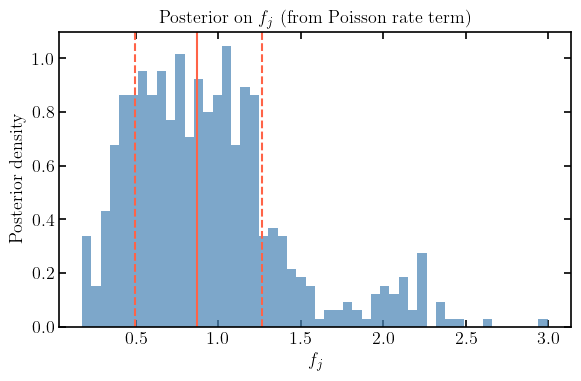

In [20]:
fj_samples = flat_samples[:, -1]

n_bns_yr  = len(sim_params.z_arr)
geo_eff   = 1 - np.cos(sim_params.theta_v_max)

# Expected GRBs per year visible to GBM (before detection efficiency)
rate_per_yr = n_bns_yr * fj_samples * geo_eff * GBM_EFF

print("fj posterior:")
fj_lo, fj_med, fj_hi = np.percentile(fj_samples, [16, 50, 84])
print(f"  fj = {fj_med:.4f}  +{fj_hi-fj_med:.4f}  -{fj_med-fj_lo:.4f}")

print("\nImplied GRB rate visible to GBM (before detection efficiency):")
r_lo, r_med, r_hi = np.percentile(rate_per_yr, [16, 50, 84])
print(f"  {r_med:.1f}  +{r_hi-r_med:.1f}  -{r_med-r_lo:.1f}  sGRBs/yr")

print(f"\nObserved rate in catalogue : {sim_params.yearly_rate:.2f} sGRBs/yr")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(fj_samples, bins=50, density=True, color="steelblue", alpha=0.7)
for q, ls in zip([fj_lo, fj_med, fj_hi], ["--", "-", "--"]):
    ax.axvline(q, color="tomato", ls=ls, lw=1.5)
ax.set_xlabel(r"$f_j$")
ax.set_ylabel("Posterior density")
ax.set_title(r"Posterior on $f_j$ (from Poisson rate term)")
fig.tight_layout()
fig.savefig(output_dir / "fj_posterior.pdf", bbox_inches="tight")
plt.show()

## 12. Alternative: PCA-whitened binned likelihood

`log_likelihood_fj_pca` replaces the four independent CvM scores with a
**PCA-whitened, quantile-binned multinomial shape term**.

### Why bother?

The four observables $(T_{90},\,E_p,\,F_p,\,\text{Fluence})$ are correlated —
e.g. bright events tend to have higher fluence.  The CvM approach treats the
four 1-D marginals as independent, discarding that joint information.

### The whitening strategy

1. Stack the four log10-observables into an $(N_{\rm obs}\times 4)$ matrix.
2. Compute the $4\times 4$ sample covariance and diagonalise it (PCA).
3. Rotate **both** observed and simulated data into the eigenvector basis $\mathbf{x}'$.
   In this basis linear correlations vanish, so the factorisation
   $P(\mathbf{x}')\approx\prod_i P(x_i')$ is much stronger.
4. For each of the 4 PCs, define **8 equal-probability bins** from the observed
   $x_i'$ projections, then estimate the model PDF from the simulated projections.
5. Accumulate the multinomial log-likelihood:

$$\ln\mathcal{L}_{\rm shape} = \sum_{i=1}^{4}\sum_b n_{{\rm obs},b}^{(i)}\,\ln p_{{\rm sim},b}^{(i)}$$

The Poisson rate term (constraining $f_j$) is unchanged and enters **once**,
exactly as in `log_likelihood_fj`.

### Pre-computing the PCA transform

Because the PCA is fitted on the **fixed** observed data it never changes
between MCMC steps.  Call `precompute_pca_transform(sim_params)` once, then
pass the result to every `log_likelihood_fj_pca` call — this saves 4 numpy
linear-algebra calls per likelihood evaluation.


In [21]:
%load_ext autoreload
%autoreload 2

from src.structured_jet import log_likelihood_fj_pca, precompute_pca_transform

# ── Pre-compute PCA transform once — fixed for the entire MCMC run ──────────
# The transform is fitted on the observed data inside sim_params.
# Passing it to every log_prob call avoids repeating the eigen-decomposition.
pca_transform = precompute_pca_transform(sim_params)

mu_pca, V_pca = pca_transform
print("PCA mean of log10-observables (T90, Ep, Fp, Fluence):")
obs_labels = ["log10(T90)", "log10(Ep)", "log10(Fp)", "log10(Fluence)"]
for lbl, m in zip(obs_labels, mu_pca):
    print(f"  {lbl:20s}: {m:+.3f}")

print("\nPCA eigenvector matrix V  (columns = PCs sorted by descending variance):")
print(np.array2string(V_pca, precision=3, suppress_small=True))

# Fraction of total variance explained by each PC
_C      = np.cov(np.column_stack([
    np.log10(sim_params.duration_data),
    np.log10(sim_params.epeak_data),
    np.log10(sim_params.pflux_data),
    np.log10(sim_params.fluence_data),
]).T)
_eigvals = np.linalg.eigh(_C)[0][::-1]     # descending
var_explained = _eigvals / _eigvals.sum()
print("\nVariance explained by each PC:")
for i, v in enumerate(var_explained):
    print(f"  PC{i+1}: {v:.1%}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PCA mean of log10-observables (T90, Ep, Fp, Fluence):
  log10(T90)          : -0.410
  log10(Ep)           : +2.727
  log10(Fp)           : +0.947
  log10(Fluence)      : -6.458

PCA eigenvector matrix V  (columns = PCs sorted by descending variance):
[[-0.434  0.837  0.086 -0.322]
 [-0.16  -0.017 -0.983 -0.092]
 [-0.43  -0.517  0.147 -0.726]
 [-0.776 -0.179  0.073  0.601]]

Variance explained by each PC:
  PC1: 50.1%
  PC2: 28.0%
  PC3: 19.7%
  PC4: 2.2%


### Visual check: corner plot of observables before and after PCA

The left panel shows the four log10-observables in their original (correlated) basis.
The right panel shows the same data projected into the PCA eigenvector basis.

If the PCA whitening works correctly, the off-diagonal scatter in the right panel
should be **visually uncorrelated** (roughly circular / axis-aligned).  Residual
non-linear correlations may remain — these are second-order effects that the 1-D
binned factorisation handles well enough for the multinomial shape term
(see `pca_wilks_proof.md` for the formal argument).

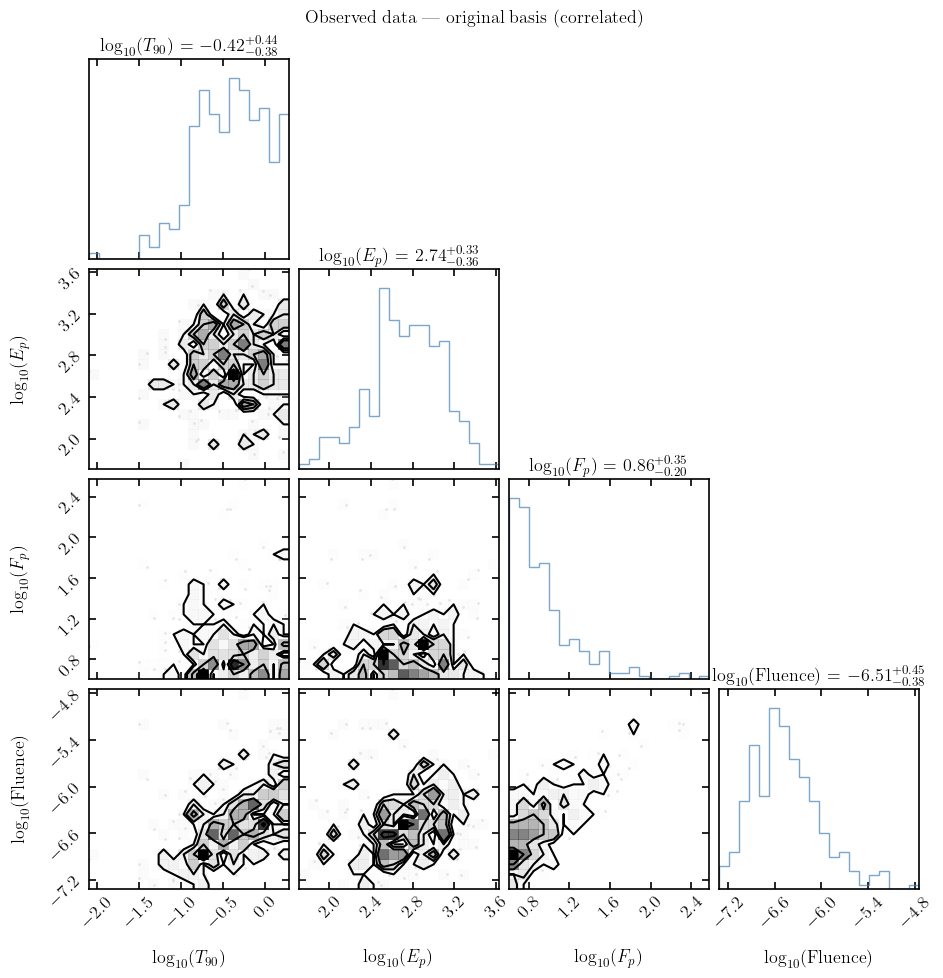

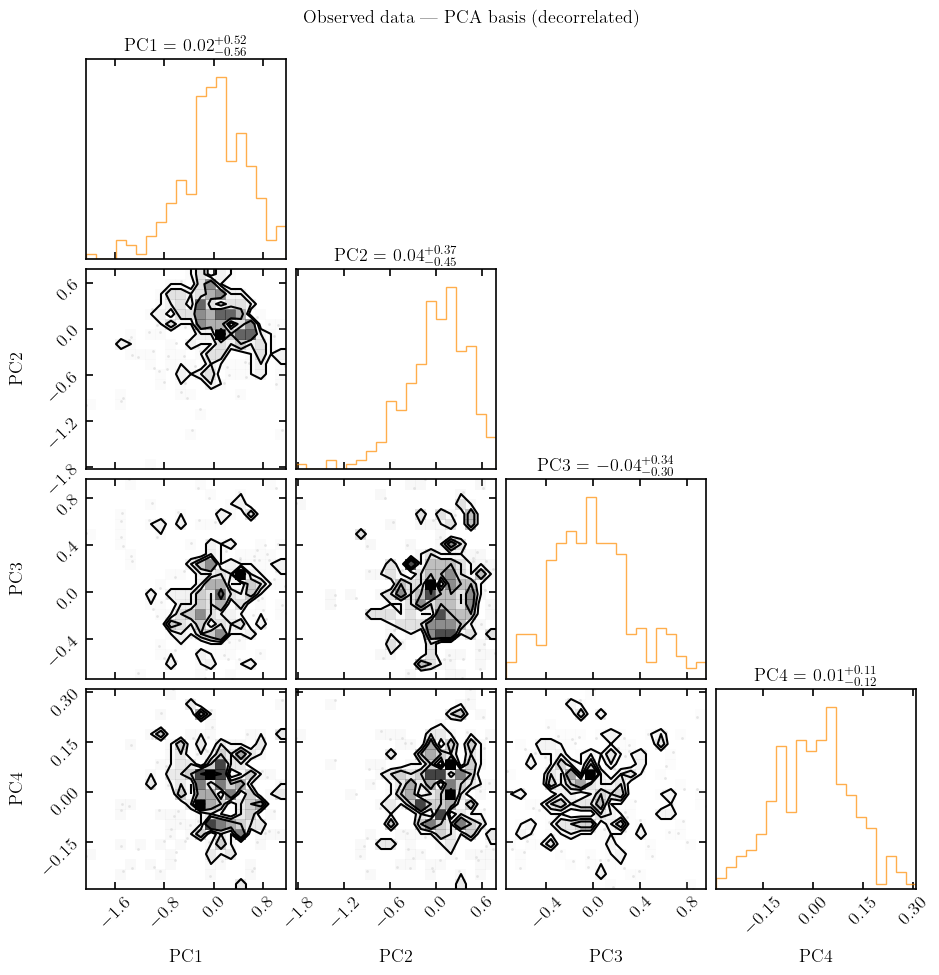

Correlation matrix — original basis:
  $\log_{10}(T_{90})$           : +1.000  +0.060  -0.086  +0.404
  $\log_{10}(E_p)$              : +0.060  +1.000  +0.051  +0.187
  $\log_{10}(F_p)$              : -0.086  +0.051  +1.000  +0.767
  $\log_{10}(\mathrm{Fluence})$ : +0.404  +0.187  +0.767  +1.000

Correlation matrix — PCA basis:
  PC1   : +1.000  +0.000  -0.000  +0.000
  PC2   : +0.000  +1.000  +0.000  +0.000
  PC3   : -0.000  +0.000  +1.000  +0.000
  PC4   : +0.000  +0.000  +0.000  +1.000


In [22]:
import corner

# ── Build the observed data matrices ─────────────────────────────────────────
obs_log = np.column_stack([
    np.log10(sim_params.duration_data),
    np.log10(sim_params.epeak_data),
    np.log10(sim_params.pflux_data),
    np.log10(sim_params.fluence_data),
])
labels_orig = [
    r"$\log_{10}(T_{90})$",
    r"$\log_{10}(E_p)$",
    r"$\log_{10}(F_p)$",
    r"$\log_{10}(\mathrm{Fluence})$",
]

# ── Project into PCA basis ───────────────────────────────────────────────────
obs_pca_proj = (obs_log - mu_pca) @ V_pca
labels_pca = [f"PC{i+1}" for i in range(4)]

# ── Side-by-side corner plots ────────────────────────────────────────────────
fig_orig = corner.corner(
    obs_log,
    labels=labels_orig,
    color="k",
    hist_kwargs=dict(density=True, color="steelblue", alpha=0.7),
    plot_contours=True,
    show_titles=True,
    title_fmt=".2f",
)
fig_orig.suptitle("Observed data — original basis (correlated)", fontsize=13, y=1.01)
fig_orig.savefig(output_dir / "corner_obs_original.pdf", bbox_inches="tight")
plt.show()

fig_pca = corner.corner(
    obs_pca_proj,
    labels=labels_pca,
    color="k",
    hist_kwargs=dict(density=True, color="darkorange", alpha=0.7),
    plot_contours=True,
    show_titles=True,
    title_fmt=".2f",
)
fig_pca.suptitle("Observed data — PCA basis (decorrelated)", fontsize=13, y=1.01)
fig_pca.savefig(output_dir / "corner_obs_pca.pdf", bbox_inches="tight")
plt.show()

# ── Print correlation matrices for quantitative check ────────────────────────
print("Correlation matrix — original basis:")
corr_orig = np.corrcoef(obs_log.T)
for i, row in enumerate(corr_orig):
    print(f"  {labels_orig[i]:30s}: " + "  ".join(f"{r:+.3f}" for r in row))

print("\nCorrelation matrix — PCA basis:")
corr_pca = np.corrcoef(obs_pca_proj.T)
for i, row in enumerate(corr_pca):
    print(f"  {labels_pca[i]:6s}: " + "  ".join(f"{r:+.3f}" for r in row))

In [23]:
# ── Drop-in replacement for log_probability that uses the PCA likelihood ────
#
# Blobs order is the same: (yearly_rate, logL_pc0, logL_pc1, logL_pc2, logL_pc3)
# so the chain diagnostics cells (§8) work without modification if you swap
# log_probability → log_probability_pca in the run_mcmc_parallel call.

N_BINS_PCA = 8   # quantile bins per PC dimension

def log_probability_pca(thetas):
    lp = log_prior(thetas)
    if not np.isfinite(lp):
        return -inf, None, None, None, None, None
    ll, yr_rate, lPC0, lPC1, lPC2, lPC3 = log_likelihood_fj_pca(
        thetas,
        sim_params,
        interps,
        limits        = DEFAULT_LIMITS,
        n_bins        = N_BINS_PCA,
        pca_transform = pca_transform,   # pre-computed above — avoids refit each call
    )
    return lp + ll, yr_rate, lPC0, lPC1, lPC2, lPC3

# ── Quick sanity check ───────────────────────────────────────────────────────
thetas_test = [2.5, -0.5, 3.2, 0.35, -0.3, 0.7, 0.15]
result_pca  = log_probability_pca(thetas_test)
print(f"log_prob_pca at test point : {result_pca[0]:.3f}")
print(f"  log_prob_cvm             : {log_probability(thetas_test)[0]:.3f}   (CvM baseline)")
print(f"  PC0 shape logL           : {result_pca[2]:.3f}")
print(f"  PC1 shape logL           : {result_pca[3]:.3f}")
print(f"  PC2 shape logL           : {result_pca[4]:.3f}")
print(f"  PC3 shape logL           : {result_pca[5]:.3f}")


log_prob_pca at test point : -2469.517
  log_prob_cvm             : -108.129   (CvM baseline)
  PC0 shape logL           : -629.470
  PC1 shape logL           : -563.352
  PC2 shape logL           : -637.825
  PC3 shape logL           : -573.575


In [24]:
output_dir_pca = create_run_dir(
     "structured_jet/fj_run_pca",
     use_timestamp=True,
     output_files_default="../Output_files",
)
backend_pca = emcee.backends.HDFBackend(str(output_dir_pca / "emcee_pca.h5"))
#
blobs_dtype_pca = [
     ("yearly_rate", float),
     ("logL_pc0",    float),
     ("logL_pc1",    float),
     ("logL_pc2",    float),
     ("logL_pc3",    float),
 ]
#
run_mcmc_parallel(
    log_probability = log_probability_pca,
    initial_pos     = initial_pos,        # same walkers as the CvM run
    max_n           = N_STEPS*10,
    backend         = backend_pca,
    blobs_dtype     = blobs_dtype_pca,
    progress        = True,
)
print(f"PCA chain saved to {output_dir_pca / 'emcee_pca.h5'}")

Creating new directory : ../Output_files/structured_jet/fj_run_pca__2026-03-07_19-40-38
Running MCMC with 11 workers (20000 steps)...


100%|██████████| 20000/20000 [1:20:31<00:00,  4.14it/s]

✓ MCMC complete (parallel). Mean acceptance: 0.003
PCA chain saved to ../Output_files/structured_jet/fj_run_pca__2026-03-07_19-40-38/emcee_pca.h5


In [25]:
reader_pca          = emcee.backends.HDFBackend(str(output_dir_pca / "emcee_pca.h5"), read_only=True)
flat_samples_pca    = reader_pca.get_chain(discard=1000, thin=10, flat=True)

In [26]:
# Re-open the backend as read-only for analysis
reader_pca          = emcee.backends.HDFBackend(str(output_dir_pca / "emcee_pca.h5"), read_only=True)
print(f"Chain shape : {reader_pca.get_chain().shape}   (steps, walkers, ndim)")
print(f"Acceptance  : {reader_pca.accepted.mean() / reader_pca.iteration:.3f} (mean fraction)")

try:
    tau = reader_pca.get_autocorr_time(tol=0)
    print(f"\nAutocorrelation times:")
    param_names = ["k", "L_L0", "L_mu_E", "sigma_E", "L_mu_tau", "sigma_tau", "fj"]
    for n, t in zip(param_names, tau):
        print(f"  {n:12s}: {t:.1f} steps")
    burn_in = int(3 * np.max(tau))
    thin    = max(1, int(0.5 * np.min(tau)))
    print(f"\nSuggested burn-in : {burn_in} steps")
    print(f"Suggested thinning: every {thin} steps")
except emcee.autocorr.AutocorrError as e:
    print(f"Autocorr not converged yet: {e}")
    burn_in = N_STEPS // 4
    thin    = 1

Chain shape : (20000, 32, 7)   (steps, walkers, ndim)
Acceptance  : 0.003 (mean fraction)

Autocorrelation times:
  k           : 1996.8 steps
  L_L0        : 1844.1 steps
  L_mu_E      : 2020.6 steps
  sigma_E     : 1990.6 steps
  L_mu_tau    : 2094.1 steps
  sigma_tau   : 2108.0 steps
  fj          : 2423.4 steps

Suggested burn-in : 7270 steps
Suggested thinning: every 922 steps


In [27]:
N_PPC = 100   # number of posterior samples to use
 
# For PPC we use the same geometric exposure as the likelihood so the
# simulated catalogue and the observed one have matching effective volumes.
# n_events_check was computed in the logprob cell.
rng_ppc         = np.random.default_rng(0)
idx_ppc         = rng_ppc.integers(0, len(flat_samples_pca), N_PPC)
ppc_samples     = flat_samples_pca[idx_ppc]

ppc_results = []
for theta in ppc_samples:
    pop = generate_grb_population(
        theta, sim_params, interps,
        limits=DEFAULT_LIMITS,
        n_events=n_events_check,
    )
    if pop is not None:
        ppc_results.append(pop)

print(f"MC draw size per PPC realisation : {n_events_check:,}")
print(f"PPC realisations with detections : {len(ppc_results)} / {N_PPC}")

MC draw size per PPC realisation : 95,440
PPC realisations with detections : 100 / 100


Flat samples shape: (32000, 7)


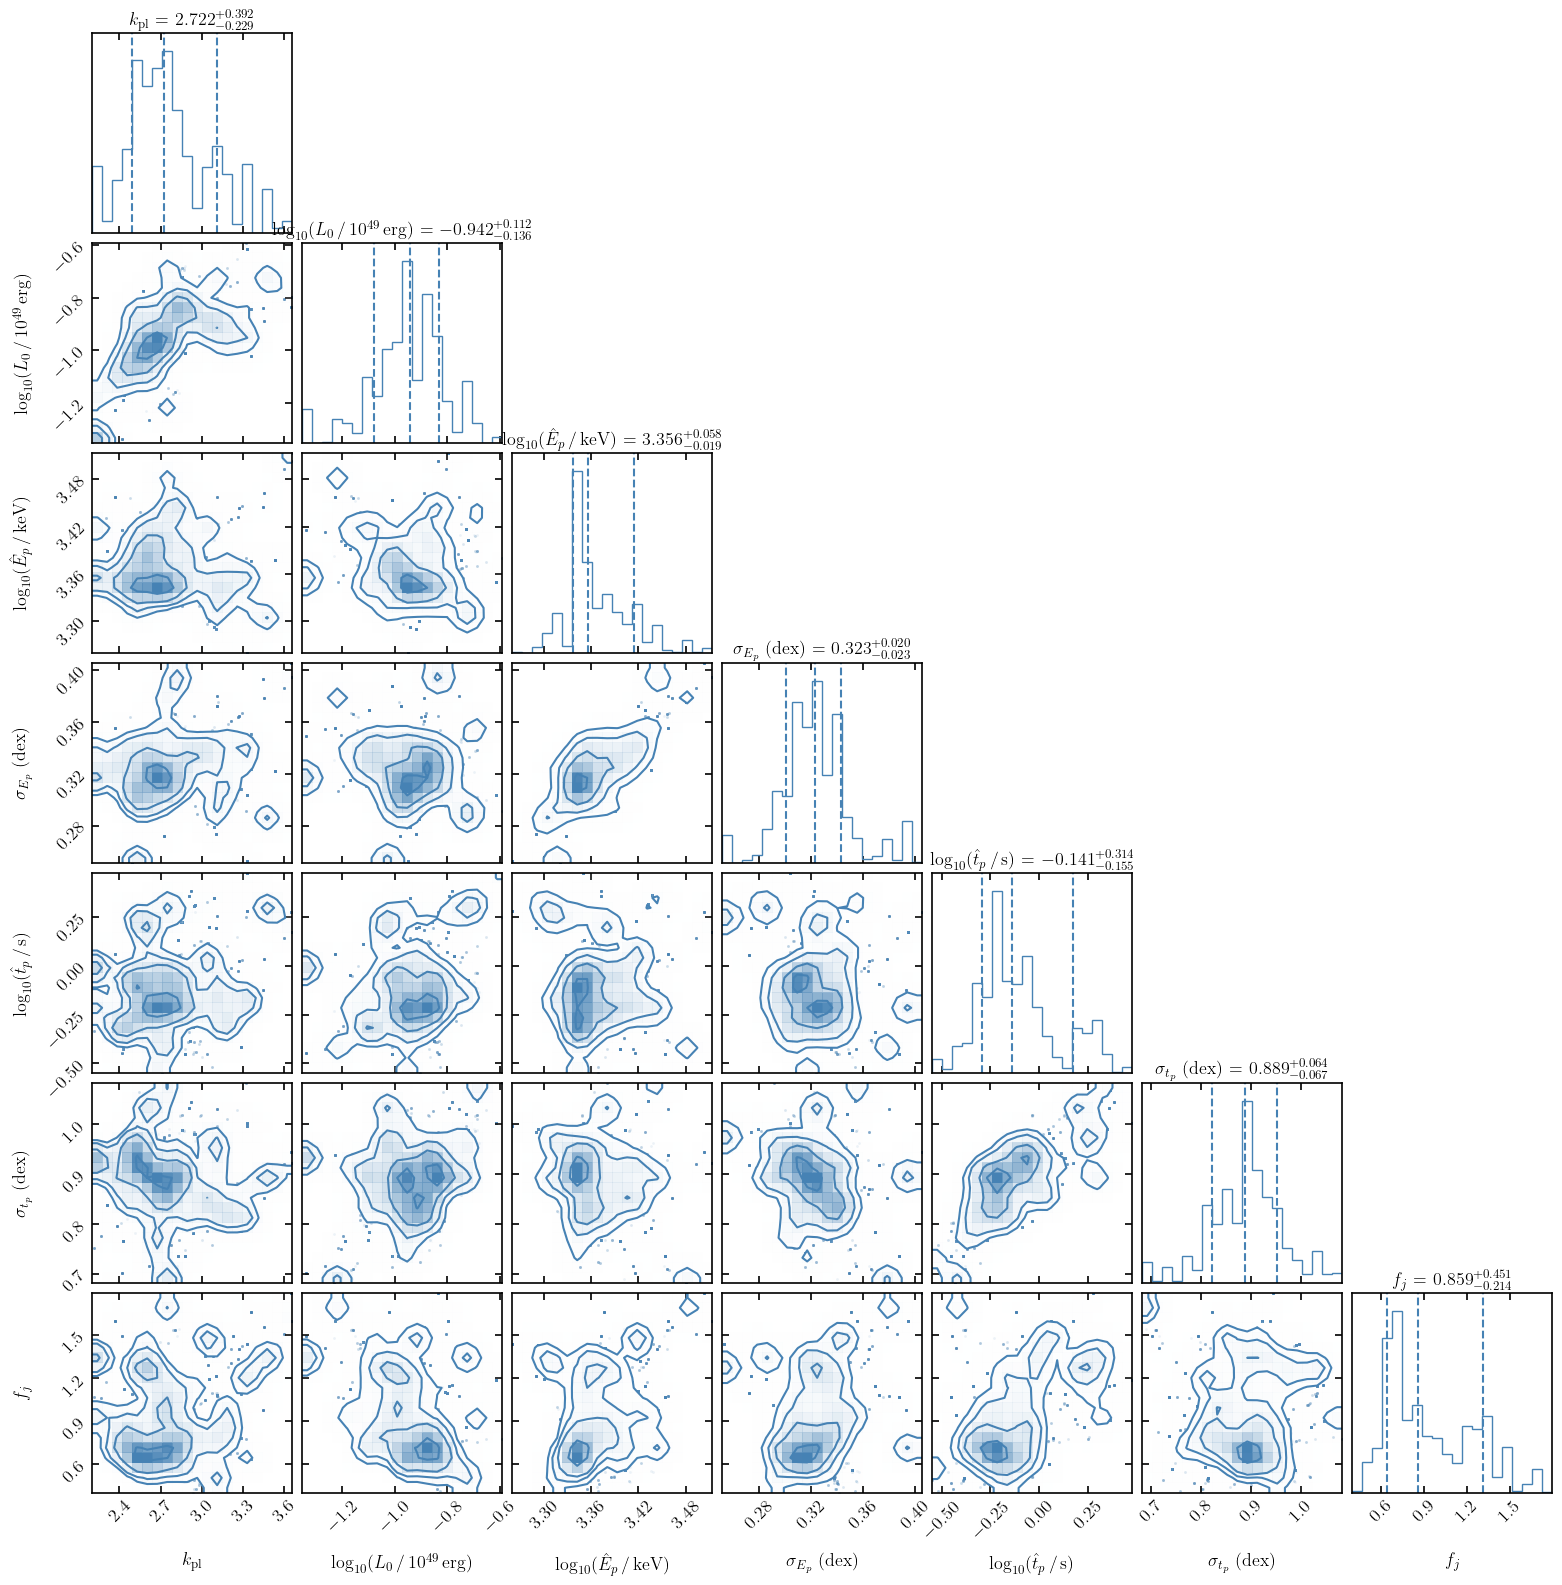


Posterior medians and 1-σ intervals:
  $k_{\rm pl}$                                 : +2.722  +0.392  -0.229
  $\log_{10}(L_0\,/\,10^{49}\,{\rm erg})$      : -0.942  +0.112  -0.136
  $\log_{10}(\hat{E}_p\,/\,{\rm keV})$         : +3.356  +0.058  -0.019
  $\sigma_{E_p}$  (dex)                        : +0.323  +0.020  -0.023
  $\log_{10}(\hat{t}_p\,/\,{\rm s})$           : -0.141  +0.314  -0.155
  $\sigma_{t_p}$  (dex)                        : +0.889  +0.064  -0.067
  $f_j$                                        : +0.859  +0.451  -0.214


In [28]:
import corner

flat_samples = reader_pca.get_chain(discard=10_000, thin=10, flat=True)
print(f"Flat samples shape: {flat_samples.shape}")

param_labels = [
    r"$k_{\rm pl}$",
    r"$\log_{10}(L_0\,/\,10^{49}\,{\rm erg})$",
    r"$\log_{10}(\hat{E}_p\,/\,{\rm keV})$",
    r"$\sigma_{E_p}$  (dex)",
    r"$\log_{10}(\hat{t}_p\,/\,{\rm s})$",
    r"$\sigma_{t_p}$  (dex)",
    r"$f_j$",
]

fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    smooth=1.0,
    color="steelblue",
)
fig.savefig(output_dir / "corner_posterior.pdf", bbox_inches="tight")
plt.show()

# Print median + 1-sigma
print("\nPosterior medians and 1-σ intervals:")
for label, p in zip(param_labels, flat_samples.T):
    lo, med, hi = np.percentile(p, [16, 50, 84])
    print(f"  {label:45s}: {med:+.3f}  +{hi-med:.3f}  -{med-lo:.3f}")

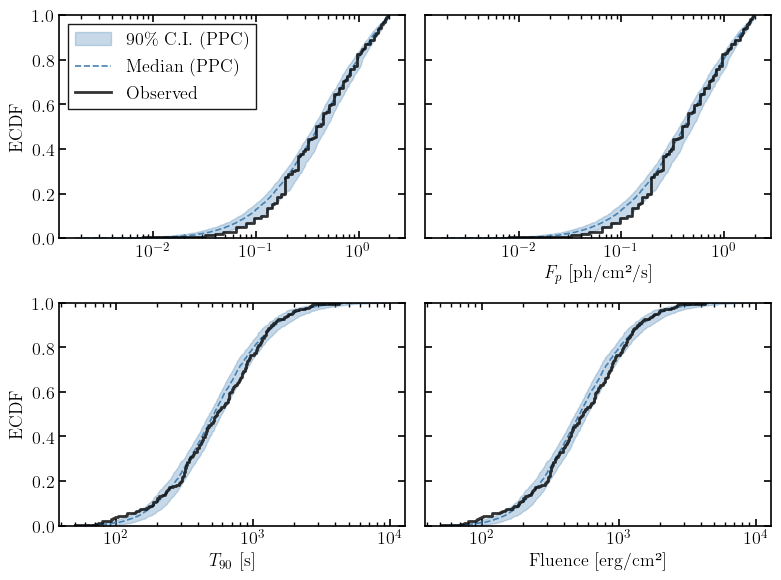

In [29]:
obs_data = {
    r"$T_{90}$ [s]"      : (sim_params.duration_data, "t90",     "log"),
    r"$E_p$ [keV]"       : (sim_params.epeak_data,    "epeak",   "log"),
    r"$F_p$ [ph/cm²/s]"  : (sim_params.pflux_data,    "pflux",   "log"),
    r"Fluence [erg/cm²]" : (sim_params.fluence_data,  "fluence", "log"),
}

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharey=True)

for axs, (label, (obs, key, scale)) in zip(axes, obs_data.items()):
    for ax in axs:
        # ── common x-grid covering both observed and simulated ranges ────────────
        all_vals = np.concatenate(
            [obs] + [pop[key] for pop in ppc_results if len(pop[key]) > 0]
        )
        x_grid = np.logspace(np.log10(all_vals.min()), np.log10(all_vals.max()), 500)

        # ── evaluate each PPC ECDF on the common grid ────────────────────────────
        ppc_cdfs = []
        for pop in ppc_results:
            sim_vals = pop[key]
            if len(sim_vals) > 0:
                sim_sorted = np.sort(sim_vals)
                sim_cdf    = np.arange(1, len(sim_sorted) + 1) / len(sim_sorted)
                # interpolate onto shared grid (flat outside range)
                ppc_cdfs.append(np.interp(x_grid, sim_sorted, sim_cdf,
                                        left=0.0, right=1.0))

        ppc_cdfs = np.array(ppc_cdfs)   # (n_ppc, n_grid)

        # ── 90% C.I. band ────────────────────────────────────────────────────────
        lo_band = np.percentile(ppc_cdfs,  5, axis=0)
        hi_band = np.percentile(ppc_cdfs, 95, axis=0)
        med_band = np.percentile(ppc_cdfs, 50, axis=0)

        ax.fill_between(x_grid, lo_band, hi_band,
                        color="steelblue", alpha=0.3, label="90\% C.I. (PPC)")
        ax.plot(x_grid, med_band, color="steelblue", lw=1.2, ls="--", label="Median (PPC)")

        # ── Observed ECDF ────────────────────────────────────────────────────────
        obs_sorted = np.sort(obs)
        obs_cdf    = np.arange(1, len(obs_sorted) + 1) / len(obs_sorted)
        ax.step(obs_sorted, obs_cdf, where="post",
                color="k", lw=2, label="Observed", zorder=5, alpha=0.8)

        ax.set_xscale("log")
        ax.set_ylim(0, 1)

axes[1, 0].set_xlabel(r"$T_{90}$ [s]")
axes[1, 1].set_xlabel(r"$E_p$ [keV]")
axes[0, 1].set_xlabel(r"$F_p$ [ph/cm²/s]")
axes[1, 1].set_xlabel(r"Fluence [erg/cm²]")
axes[0, 0].set_ylabel("ECDF")
axes[1, 0].set_ylabel("ECDF")
axes[0, 0].legend()

fig.tight_layout()
fig.savefig(output_dir / "ppc.pdf", bbox_inches="tight")
plt.show()

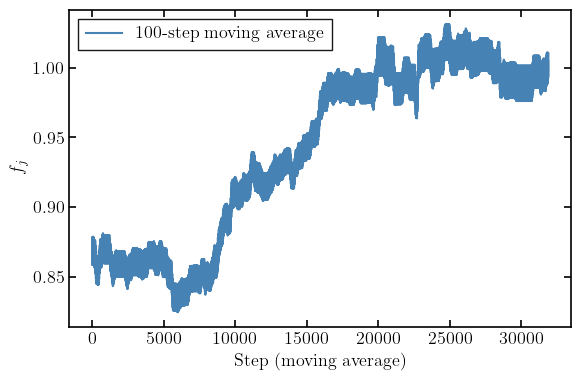

In [30]:
fj_samples = flat_samples[:, -1]

average_window = 100
fj_samples_avg_100 = np.convolve(fj_samples, np.ones(average_window)/average_window, mode='valid')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fj_samples_avg_100, color="steelblue", lw=1.5, label=f"{average_window}-step moving average")
ax.set_xlabel("Step (moving average)")
ax.set_ylabel(r"$f_j$")
ax.legend()
fig.tight_layout()
plt.show() 

## 13. Diagnostic: rigour of the evolving k-factor approximation

The bolometric normalisation is computed as:

$$
I_1^{\rm approx} = \underbrace{1.15739}_{\substack{\text{time integral of }P_n(t)/t_\mathrm{peak}\\ \text{at fixed }\alpha_n = 2.521}} \times t_\mathrm{peak} \times \int_{\rm bol} N(E;\, \hat{E}_p)\,dE
$$

This bundles two approximations:

| # | Approximation | Exact quantity |
|---|---------------|----------------|
| A | $\alpha_n$ fixed at 2.521 | per-event $\alpha_n(\theta_v)$ from angular table |
| B | k-factor evaluated at peak $\hat{E}_p$ | k-factor integrated over $\hat{E}_p(t) = \hat{E}_p\,(t/t_{\rm peak})^{-\alpha_e}$ during decay |

The exact normalisation is:

$$
I_1^{\rm exact} = \int_0^\infty P_n(t)\, \int_{\rm bol} N\!\left(E;\,\hat{E}_p(t)\right) dE\; dt
$$

The cell below draws a representative sample at the posterior medians, numerically integrates $I_1^{\rm exact}$, and compares it to $I_1^{\rm approx}$ (and the intermediate fix-A-only estimate) to assess the bias in $N_0$ and hence in $F_p$ and $E_{\rm iso}$.

In [31]:
from scipy.integrate import quad
import warnings

# ── Posterior medians (from the run above) ───────────────────────────────────
# [k, L_L0, L_mu_E, sigma_E, L_mu_tau, sigma_tau, fj]
thetas_med = [2.723, -0.982, 3.396, 0.345, -0.483, 0.764, 0.677]
k_pl, L_L0, L_mu_E_10, sigma_E_10, L_mu_tau_10, sigma_tau_10, fj_med = thetas_med

# ── Draw intrinsic (pre-angle-modulation) parameters ─────────────────────────
# We draw E_p_hat and t_peak from their lognormal intrinsic distributions so
# that int_0_alt is evaluated at the true rest-frame peak energy before the
# R_E viewing-angle modulation is applied.  alpha_n and alpha_e are taken from
# the same viewing-angle table that is used in the production pipeline.

N_EXACT = 2_000
rng_diag = np.random.default_rng(99)
l_10 = np.log(10)

# Intrinsic (on-axis) E_p and t_peak in rest frame
E_p_hat = rng_diag.lognormal(mean=L_mu_E_10   * l_10, sigma=sigma_E_10   * l_10, size=N_EXACT)
t_peak  = rng_diag.lognormal(mean=L_mu_tau_10  * l_10, sigma=sigma_tau_10 * l_10, size=N_EXACT)

# Per-event alpha_n and alpha_e from the viewing-angle table
N_theta  = len(sim_params.alpha_n)
idx_th   = rng_diag.integers(0, N_theta, size=N_EXACT)
alpha_n  = sim_params.alpha_n[idx_th]
alpha_e  = sim_params.alpha_e[idx_th]

# ── Three estimates of I1 ────────────────────────────────────────────────────
# ------ Approximation (as in production code) --------------------------------
# Assumes alpha_n = 2.521 for ALL events via the 1.15739 constant:
#   time integral = integral_0^{tp} (t/tp) dt  +  integral_{tp}^inf (t/tp)^{-2.521} dt
#                 = tp/2  +  tp/1.521  =  1.15739 * tp
# k-factor frozen at peak E_p_hat (no spectral evolution)
I1_approx = 1.15739 * t_peak * interps.int_0_alt(E_p_hat)

# ------ Fix A: per-event alpha_n, but k-factor still frozen at E_p_hat ------
# time integral = tp/2  +  tp/(alpha_n - 1)
time_int_exact = t_peak * (0.5 + 1.0 / np.maximum(alpha_n - 1.0, 0.01))
I1_fixA        = time_int_exact * interps.int_0_alt(E_p_hat)

# ------ Exact: per-event alpha_n AND time-evolving k-factor -----------------
# I1 = integral_0^tp (t/tp) * int_bol(E_p_hat) dt              [rise: P_e = 1]
#    + integral_tp^inf (t/tp)^{-an} * int_bol(E_p_hat*(t/tp)^{-ae}) dt  [decay]
# The rise phase is the same for fix-A and exact (P_e = 1 during rise).
# Only the decay integral differs.

def I1_exact_single(tp, an, ae, Ep_hat_i, t_max_factor=300):
    """Exact I1 for one event via numerical integration (rest-frame quantities)."""
    ib_peak = float(interps.int_0_alt(np.array([Ep_hat_i]))[0])

    # Rise phase: P_e = 1 → int_bol = constant
    rise = 0.5 * tp * ib_peak

    # Decay phase: P_e = (t/tp)^{-ae} → int_bol depends on time
    def integrand(t):
        ratio  = t / tp
        Ep_t   = Ep_hat_i * ratio**(-ae)
        return ratio**(-an) * float(interps.int_0_alt(np.array([Ep_t]))[0])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        decay, _ = quad(integrand, tp, tp * t_max_factor, limit=300)

    return rise + decay

I1_exact_arr = np.array([
    I1_exact_single(t_peak[i], alpha_n[i], alpha_e[i], E_p_hat[i])
    for i in range(N_EXACT)
])

# ── Ratios ───────────────────────────────────────────────────────────────────
# R > 1 → approximation over-estimates I1 → under-estimates N0 → under-estimates F_p
R_approx = I1_approx       / I1_exact_arr
R_fixA   = I1_fixA         / I1_exact_arr

print("I1 ratio statistics  (approximation / exact)")
print("  R > 1 means the approximation OVERestimates I1")
print("  (which UNDERestimates N0 and hence F_p / fluence)\n")
print(f"  N events = {N_EXACT:,}")
print()
print("  I1_approx / I1_exact  (frozen alpha_n = 2.521  + frozen k-factor):")
print(f"    mean   = {R_approx.mean():.4f}  ({(R_approx.mean()-1)*100:+.2f}%)")
print(f"    median = {np.median(R_approx):.4f}  ({(np.median(R_approx)-1)*100:+.2f}%)")
print(f"    std    = {R_approx.std():.4f}  ({R_approx.std()*100:.2f}%  rms scatter)")
print(f"    5–95%  : [{np.percentile(R_approx, 5):.4f}, {np.percentile(R_approx, 95):.4f}]")
print()
print("  I1_fixA / I1_exact  (per-event alpha_n, frozen k-factor):")
print(f"    mean   = {R_fixA.mean():.4f}  ({(R_fixA.mean()-1)*100:+.2f}%)")
print(f"    median = {np.median(R_fixA):.4f}  ({(np.median(R_fixA)-1)*100:+.2f}%)")
print(f"    std    = {R_fixA.std():.4f}  ({R_fixA.std()*100:.2f}%  rms scatter)")
print(f"    5–95%  : [{np.percentile(R_fixA, 5):.4f}, {np.percentile(R_fixA, 95):.4f}]")
print()

# Decompose variance contribution from each approximation
Rdiff_A = R_approx - R_fixA   # residual due to fixed alpha_n
Rdiff_B = R_fixA   - 1.0      # residual due to frozen k-factor
var_A = np.var(Rdiff_A)
var_B = np.var(Rdiff_B)
print(f"  Variance decomposition:")
print(f"    frozen alpha_n  contributes {var_A/(var_A+var_B+1e-30)*100:.1f}% of total variance")
print(f"    frozen k-factor contributes {var_B/(var_A+var_B+1e-30)*100:.1f}% of total variance")

I1 ratio statistics  (approximation / exact)
  R > 1 means the approximation OVERestimates I1
  (which UNDERestimates N0 and hence F_p / fluence)

  N events = 2,000

  I1_approx / I1_exact  (frozen alpha_n = 2.521  + frozen k-factor):
    mean   = 0.6473  (-35.27%)
    median = 0.6233  (-37.67%)
    std    = 0.1091  (10.91%  rms scatter)
    5–95%  : [0.5054, 0.8553]

  I1_fixA / I1_exact  (per-event alpha_n, frozen k-factor):
    mean   = 56.2043  (+5520.43%)
    median = 54.1252  (+5312.52%)
    std    = 9.4752  (947.52%  rms scatter)
    5–95%  : [43.8862, 74.2657]

  Variance decomposition:
    frozen alpha_n  contributes 49.4% of total variance
    frozen k-factor contributes 50.6% of total variance


/home/ludo/miniconda3/envs/acme_env/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


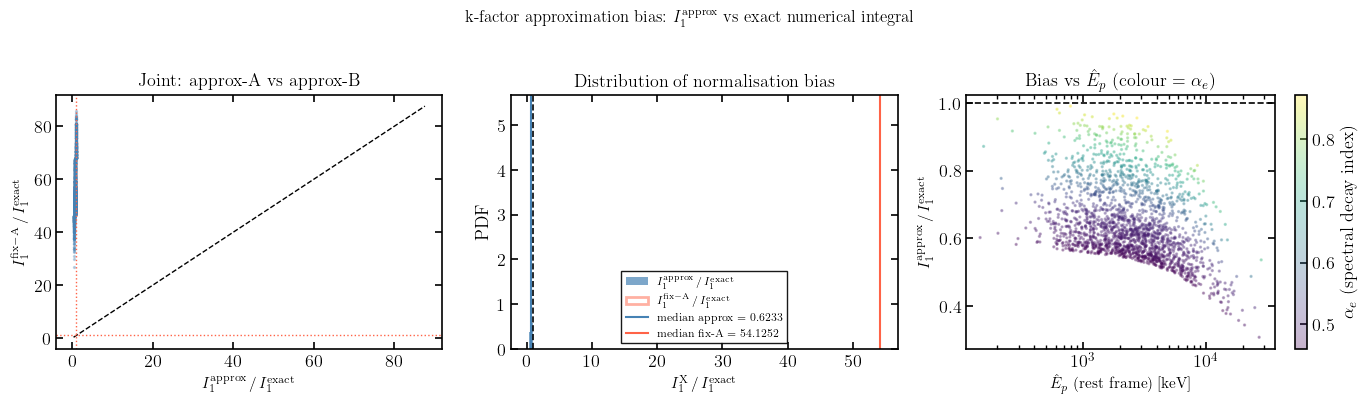

Implied fractional bias on F_p  (1/R_approx = exact/approx,  1.0 = no bias):
  mean   = 1.5876  (+58.76%)
  median = 1.6043  (+60.43%)
  std    = 0.2603  (26.03% rms scatter)

Note: E_iso ∝ N0 × I1 — any bias in I1 cancels, so E_iso is unaffected.
      F_p and fluence share the same fractional bias as N0.


In [32]:
# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel 1: joint distribution of both ratios
ax = axes[0]
ax.scatter(R_approx, R_fixA, s=2, alpha=0.3, color="steelblue", rasterized=True)
lims = [min(R_approx.min(), R_fixA.min()) * 0.98,
        max(R_approx.max(), R_fixA.max()) * 1.02]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel(r"$I_1^{\rm approx}\,/\,I_1^{\rm exact}$",  fontsize=11)
ax.set_ylabel(r"$I_1^{\rm fix-A}\,/\,I_1^{\rm exact}$",   fontsize=11)
ax.set_title(r"Joint: approx-A vs approx-B")
ax.axhline(1, color="tomato", ls=":", lw=1)
ax.axvline(1, color="tomato", ls=":", lw=1)

# Panel 2: distribution of I1_approx / I1_exact
ax = axes[1]
bins = np.linspace(R_approx.min() * 0.98, R_approx.max() * 1.02, 60)
ax.hist(R_approx, bins=bins, density=True, color="steelblue", alpha=0.7,
        label=r"$I_1^{\rm approx}\,/\,I_1^{\rm exact}$")
ax.hist(R_fixA,   bins=bins, density=True, color="tomato",    alpha=0.5,
        label=r"$I_1^{\rm fix-A}\,/\,I_1^{\rm exact}$", histtype="step", lw=2)
ax.axvline(1, color="k", ls="--", lw=1.2)
ax.axvline(np.median(R_approx), color="steelblue", ls="-",  lw=1.5,
           label=f"median approx = {np.median(R_approx):.4f}")
ax.axvline(np.median(R_fixA),   color="tomato",    ls="-",  lw=1.5,
           label=f"median fix-A = {np.median(R_fixA):.4f}")
ax.set_xlabel(r"$I_1^{\rm X}\,/\,I_1^{\rm exact}$", fontsize=11)
ax.set_ylabel("PDF")
ax.legend(fontsize=8)
ax.set_title("Distribution of normalisation bias")

# Panel 3: bias vs rest-frame E_p_hat — shows where the k-factor matters most
ax = axes[2]
sc = ax.scatter(E_p_hat, R_approx, s=2, alpha=0.3,
                c=alpha_e, cmap="viridis", rasterized=True)
plt.colorbar(sc, ax=ax, label=r"$\alpha_e$ (spectral decay index)")
ax.axhline(1, color="k", ls="--", lw=1.2)
ax.set_xscale("log")
ax.set_xlabel(r"$\hat{E}_p$ (rest frame) [keV]", fontsize=11)
ax.set_ylabel(r"$I_1^{\rm approx}\,/\,I_1^{\rm exact}$", fontsize=11)
ax.set_title(r"Bias vs $\hat{E}_p$ (colour = $\alpha_e$)")

fig.suptitle(
    r"k-factor approximation bias: $I_1^{\rm approx}$ vs exact numerical integral",
    fontsize=12, y=1.01
)
fig.tight_layout()
fig.savefig(output_dir / "kfactor_diagnostic.pdf", bbox_inches="tight")
plt.show()

# ── Impact on key observables ─────────────────────────────────────────────────
# N0 ∝ 1/I1, so bias in I1 translates directly to anti-correlated bias in N0.
# F_p ∝ N0 * int_3(E_p_obs)  → same fractional bias.
# E_iso ∝ N0 * I1  → bias cancels exactly (N0 * I1 = fixed quantity).
bias_on_Fp   = 1.0 / R_approx   # fractional bias on F_p (approx/exact)
print("Implied fractional bias on F_p  (1/R_approx = exact/approx,  1.0 = no bias):")
print(f"  mean   = {bias_on_Fp.mean():.4f}  ({(bias_on_Fp.mean()-1)*100:+.2f}%)")
print(f"  median = {np.median(bias_on_Fp):.4f}  ({(np.median(bias_on_Fp)-1)*100:+.2f}%)")
print(f"  std    = {bias_on_Fp.std():.4f}  ({bias_on_Fp.std()*100:.2f}% rms scatter)")
print()
print("Note: E_iso ∝ N0 × I1 — any bias in I1 cancels, so E_iso is unaffected.")
print("      F_p and fluence share the same fractional bias as N0.")